In [25]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
import pandas as pd
import rioxarray
import matplotlib.pyplot as plt

# Set universal plot style to seaborn paper theme
uplt.rc.style = 'seaborn-v0_8-paper'
# Update plot configuration parameters
uplt.rc.update({
    'tick.len': 2.0,        # Set tick length
    'tick.dir': 'in',       # Set tick direction (inward)
    'font.largesize': 12,   # Set large font size
    'font.smallsize': 10    # Set small font size
})

# Define longitude and latitude limits for plotting
lonlim = (-82, -32)
latlim = (-60, 15)

# Load Amazon shapefile and read into GeoDataFrame
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# Dissolve all polygons into a single multi-polygon feature
# (Alternative commented line shows filtering for specific region before dissolving)
amazon_vector = amazon_vector.dissolve()
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Select the first (and only) feature from the dissolved GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

# Load global geography regions shapefile for additional geographic context
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)


In [17]:
def get_da(arr):
    # Load latitude and longitude arrays from numpy files
    lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
    lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")
    
    # Create DataFrame with values, latitudes and longitudes, then pivot to 2D grid
    df_pivot = pd.DataFrame({'values': arr, 'lat': lats, 'lon': lons}).pivot_table(
        index='lat', columns='lon', values='values')
    
    # Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinates
    da = xr.DataArray(df_pivot, dims=('lat', 'lon'), 
                     coords={'lat': df_pivot.index, 'lon': df_pivot.columns})
    
    return da

In [ ]:
ssim_np=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/ssim_somo.npy',)

In [18]:
# Create DataArray for IG-EG comparison: average SSIM values across first dimension for channel 0
ssim_ig_eg = get_da(arr=np.mean(ssim_np[:, :, 0], axis=1))

# Create DataArray for IG-SG comparison: average SSIM values across first dimension for channel 1
ssim_ig_sg = get_da(arr=np.mean(ssim_np[:, :, 1], axis=1))

# Create DataArray for SG-EG comparison: average SSIM values across first dimension for channel 2
ssim_sg_eg = get_da(arr=np.mean(ssim_np[:, :, 2], axis=1))

/tmp/ipykernel_2426435/2765280580.py:72: UltraPlotWarning: fig.subplots_adjust() has no effect on ultraplot figures. To set the left, right, bottom, top, wspace, or hspace gridspec values, pass them as keyword arguments to uplt.figure() or uplt.subplots(). Please note they are now specified in physical units, with strings interpreted by uplt.units() and floats interpreted as font size-widths.
  plt.subplots_adjust(bottom=0.10)


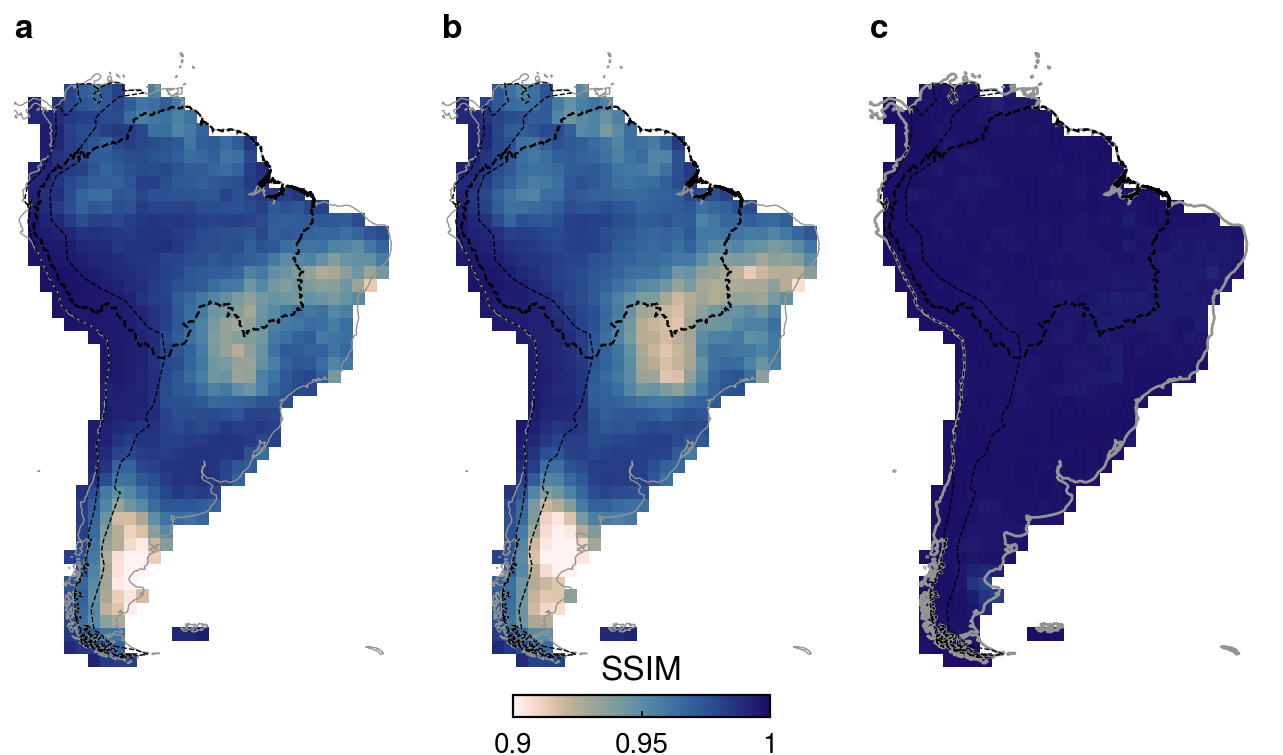

In [28]:
# Define map projection (PlateCarree commented alternative shows AlbersEqualArea option)
# proj = ccrs.AlbersEqualArea(central_longitude=-60, central_latitude=-20, standard_parallels=(-10, -40))
proj = ccrs.PlateCarree()

# Define subplot arrangement (single row with three subplots)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2, 3],
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and layout parameters
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1, 1], height_ratios=[1])
# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

# First subplot: IG-EG SSIM comparison
ax = axs[0]
# Plot SSIM values as colormesh
im = ax.pcolormesh(
    ssim_ig_eg.lon,
    ssim_ig_eg.lat,
    ssim_ig_eg.values,
    cmap='lapaz_r',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=0.9, vmax=1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Second subplot: IG-SG SSIM comparison
ax = axs[1]
# Plot SSIM values as colormesh
im = ax.pcolormesh(
    ssim_ig_sg.lon,
    ssim_ig_sg.lat,
    ssim_ig_sg.values,
    cmap='lapaz_r',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=0.9, vmax=1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Third subplot: SG-EG SSIM comparison
ax = axs[2]
# Plot SSIM values as colormesh
im = ax.pcolormesh(
    ssim_sg_eg.lon,
    ssim_sg_eg.lat,
    ssim_sg_eg.values,
    cmap='lapaz_r',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=0.9, vmax=1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Create colorbar axis below the plots
cax = fig.add_axes([0.40, 0.05, 0.2, 0.03], title='SSIM')
# Add colorbar to the figure
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='neither',
    ticks=[0.9, 0.925, 0.95, 0.975, 1],
)

# Adjust bottom margin to accommodate colorbar
plt.subplots_adjust(bottom=0.10)